# METEOR Description Paper: Seasonal and Noise Model Visualization

This notebook illustrates the capabilities of METEOR for generating ensemble members that combine seasonal patterns with realistic noise structures. We start with a global mean temperature plot comparing a 10-member METEOR ensemble for CESM2 RCP4.5 with the original experiment data.

## 1. Import Required Libraries

In [1]:
# Standard library imports
import warnings
warnings.filterwarnings('ignore')

# Third-party imports
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# METEOR import - import from the correct module
from meteor.meteor import Meteor as METEOR

## 2. Load Model Data from Cache

In [2]:
# Initialize CMIP6 data getter with cache enabled
from meteor import Cmip6MeteorDataGetter

# Set up the data getter for the experiments we need
# We'll use ssp245 (RCP4.5) along with piControl for the noise model
data_getter = Cmip6MeteorDataGetter(
    exps=["piControl", "ssp245", "historical", "abrupt-4xCO2"],
    flds=["tas"],  # Surface air temperature
    dbe=['CMIP', 'ScenarioMIP', 'CMIP', 'CMIP'   ],  # Project names for each experiment
    enable_cache=True  # Use cached data
)

print("Data getter initialized successfully!")
print(f"Available models: {data_getter.get_models_avail()}")

Data getter initialized successfully!
Available models: ['ACCESS-CM2', 'ACCESS-ESM1-5', 'AWI-CM-1-1-MR', 'BCC-CSM2-MR', 'CAMS-CSM1-0', 'CAS-ESM2-0', 'CESM2', 'CESM2-WACCM', 'CIESM', 'CMCC-CM2-SR5', 'CMCC-ESM2', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'CanESM5', 'EC-Earth3', 'EC-Earth3-CC', 'EC-Earth3-Veg', 'FGOALS-f3-L', 'FGOALS-g3', 'FIO-ESM-2-0', 'GFDL-CM4', 'GFDL-ESM4', 'GISS-E2-1-G', 'GISS-E2-1-H', 'HadGEM3-GC31-LL', 'IITM-ESM', 'INM-CM4-8', 'INM-CM5-0', 'IPSL-CM6A-LR', 'KACE-1-0-G', 'KIOST-ESM', 'MCM-UA-1-0', 'MIROC-ES2L', 'MIROC6', 'MPI-ESM1-2-HR', 'MPI-ESM1-2-LR', 'MRI-ESM2-0', 'NESM3', 'NorESM2-LM', 'NorESM2-MM', 'TaiESM1', 'UKESM1-0-LL']


## 4. Calculate Global Mean Temperature

In [3]:
def calculate_global_mean(data):
    """Calculate area-weighted global mean temperature."""
    weights = np.cos(np.deg2rad(data.lat))
    weights.name = "weights"
    data_weighted = data.weighted(weights)
    return data_weighted.mean(dim=["lat", "lon"])


## 3. Set Up Regional Analysis Tools

In [4]:
# Install and import regionmask for AR6 regional analysis
try:
    import regionmask
    print("✅ regionmask already installed")
except ImportError:
    print("📦 Installing regionmask...")
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "regionmask", "-q"])
    import regionmask
    print("✅ regionmask installed successfully")

# Load AR6 regions
ar6_regions = regionmask.defined_regions.ar6.all
print(f"✅ AR6 regions loaded: {len(ar6_regions)} regions available")


✅ regionmask already installed
✅ AR6 regions loaded: 58 regions available


In [5]:
def calculate_regional_mean(data, region_code):
    """
    Calculate area-weighted regional mean for a specific AR6 region.
    
    Parameters
    ----------
    data : xr.DataArray
        Data with dimensions including 'lat' and 'lon'
    region_code : str
        AR6 region abbreviation (e.g., 'WNA', 'NEU', 'EAS', etc.)
    
    Returns
    -------
    xr.DataArray
        Regional mean time series
    """
    # Create mask for the specified region
    mask = ar6_regions.mask(data)
    
    # Find the region number for the given code
    region_number = None
    for region in ar6_regions:
        if region.abbrev == region_code:
            region_number = region.number
            region_name = region.name
            break
    
    if region_number is None:
        raise ValueError(f"Region code '{region_code}' not found in AR6 regions")
    
    # Apply mask to data
    regional_data = data.where(mask == region_number)
    
    # Calculate area-weighted mean
    weights = np.cos(np.deg2rad(regional_data.lat))
    weights.name = "weights"
    regional_weighted = regional_data.weighted(weights)
    regional_mean = regional_weighted.mean(dim=["lat", "lon"])
    
    # Add attributes
    regional_mean.attrs['region_code'] = region_code
    regional_mean.attrs['region_name'] = region_name
    
    return regional_mean


def list_ar6_regions():
    """List all available AR6 regions with their codes and names."""
    print("AR6 IPCC Reference Regions:")
    print("=" * 60)
    for region in ar6_regions:
        print(f"  {region.abbrev:6s} : {region.name}")
    print("=" * 60)
    print(f"Total: {len(ar6_regions)} regions")



print("\navailable regions:")
list_ar6_regions()


available regions:
AR6 IPCC Reference Regions:
  GIC    : Greenland/Iceland
  NWN    : N.W.North-America
  NEN    : N.E.North-America
  WNA    : W.North-America
  CNA    : C.North-America
  ENA    : E.North-America
  NCA    : N.Central-America
  SCA    : S.Central-America
  CAR    : Caribbean
  NWS    : N.W.South-America
  NSA    : N.South-America
  NES    : N.E.South-America
  SAM    : South-American-Monsoon
  SWS    : S.W.South-America
  SES    : S.E.South-America
  SSA    : S.South-America
  NEU    : N.Europe
  WCE    : West&Central-Europe
  EEU    : E.Europe
  MED    : Mediterranean
  SAH    : Sahara
  WAF    : Western-Africa
  CAF    : Central-Africa
  NEAF   : N.Eastern-Africa
  SEAF   : S.Eastern-Africa
  WSAF   : W.Southern-Africa
  ESAF   : E.Southern-Africa
  MDG    : Madagascar
  RAR    : Russian-Arctic
  WSB    : W.Siberia
  ESB    : E.Siberia
  RFE    : Russian-Far-East
  WCA    : W.C.Asia
  ECA    : E.C.Asia
  TIB    : Tibetan-Plateau
  EAS    : E.Asia
  ARP    : Arabian

## 5. Set Up Pattern Scaling Models

In [6]:
model_name = "CESM2"
# Import additional METEOR components for pattern scaling
from meteor import MeteorPatternScaling
import sys
from io import StringIO

# Prepare training data dictionary
training_data = {
    "base": data_getter.make_meteor_training_data("base", model_name),
    "co2x4": data_getter.make_meteor_training_data("co2x4", model_name),
    "ssp245": data_getter.make_meteor_training_data_composite(["historical", "ssp245"], model_name)
}

print("Training data prepared:")
for key, data in training_data.items():
    print(f"  {key}: {data['tas'].shape}")
    
# Use ssp245 as the aerosol anomaly experiment (sulxanom)
training_data["sulxanom"] = training_data["ssp245"]

print("\nCreating pattern scaling model with aerosol effects...")

# Suppress stdout during model creation
old_stdout = sys.stdout
sys.stdout = StringIO()

try:
    # Create aerosol-inclusive pattern scaling model
    pattern_model = MeteorPatternScaling(
        f"cmip6-{model_name}-aer",
        {"tas": 2},  # 2 patterns for temperature
        lambda key: training_data[key],
        from_file=False,
        exp_list=["base", "co2x4", "sulxanom"]
    )
finally:
    # Restore stdout
    sys.stdout = old_stdout

print(f"✅ Pattern scaling model created: {pattern_model.name}")

   Limiting piControl data to first 150 years (was 1200 years)


Training data prepared:
  base: (1, 150, 192, 288)
  co2x4: (1, 999, 192, 288)
  ssp245: (1, 251, 192, 288)

Creating pattern scaling model with aerosol effects...


✅ Pattern scaling model created: cmip6-CESM2-aer


## 6. Load Climate Forcing Data and Generate Predictions

In [7]:
# Load forcing data for SSP245
import os
from ciceroscm import input_handler

# Data directory (adjust path as needed)
cscm_data_dir = os.path.join(os.getcwd(), "..", "src", "meteor", "default_scm_data")

# Load concentration and emission data
conc_file = os.path.join(cscm_data_dir, "ssp245_conc_RCMIP.txt")
em_file = os.path.join(cscm_data_dir, "ssp245_em_RCMIP.txt")

ih = input_handler.InputHandler({})
conc_data = input_handler.read_inputfile(conc_file)
em_data = ih.read_emissions(em_file)

print(f"✅ Forcing data loaded for SSP245")
print(f"   Concentration data: {len(conc_data)} rows")
print(f"   Emission data: {len(em_data)} rows")

# Generate climate prediction using the aerosol-inclusive model
print("\n🌍 Generating climate prediction with aerosol effects...")
climate_prediction = pattern_model.predict_from_combined_experiment(
    em_data, 
    conc_data, 
    ["tas"]
)

temperature_prediction = climate_prediction["tas"]
print(f"✅ Climate prediction generated")
print(f"   Temperature shape: {temperature_prediction.shape}")


✅ Forcing data loaded for SSP245
   Concentration data: 801 rows
   Emission data: 751 rows

🌍 Generating climate prediction with aerosol effects...
11
12
113
114
115
22
141
123
142
✅ Climate prediction generated
   Temperature shape: (351, 192, 288)


## 7. Train Noise Model and Generate 10-Member Ensemble

In [8]:
# Train noise model from CMIP6 data
from meteor.noise_generator import train_noise_model_from_cmip6
from meteor import prpatt

print("🔧 Training noise model for CESM2...")

# Convert annual predictions to monthly
monthly_prediction = pattern_model.to_monthly(temperature_prediction, start_year=0)
monthly_warming = prpatt.global_mean(monthly_prediction).values

# Skip first 100 years (spin-up)
monthly_warming_trimmed = monthly_warming[1200:]  # 100 years * 12 months

# Set up noise cache directory
noise_cache_dir = os.path.join(os.getcwd(), "noise_cache")

# Train the noise model
tas_noise_model = train_noise_model_from_cmip6(
    data_getter,
    experiments=["historical", "ssp245"],
    model_name=model_name,
    variable_name="tas",
    n_modes=15,  # Number of PCA modes
    lag_order=2,  # Temporal lag
    custom_global_temp=monthly_warming_trimmed,
    use_picontrol_baseline=True,
    cache_dir=noise_cache_dir
)

print(f"✅ Noise model trained successfully")

print(f"   Training length: {len(monthly_warming_trimmed)//12} years")

🔧 Training noise model for CESM2...
   Limiting piControl data to first 150 years (was 1200 years)
   Fetched piControl baseline for CESM2 tas: 277.318
Noise generator fitted successfully.
   - PCA modes: 15
   - Variance explained: 63.82%
   - VARX lag order: 2
Model saved to /Users/bensan/Documents/Github/METEOR/notebooks/noise_cache/CESM2_tas_noise_model.pkl
✅ Noise model trained successfully
   Training length: 251 years


### Test New Fast Regional Mean Generation

Let's test the new `generate_regional_mean_realizations()` method which should be much faster!

In [9]:
# Test the new fast regional mean generation
import time

n_test = 100  # Generate 100 realizations

# Compute global mean of monthly_prediction once (for add_base)
monthly_prediction_global_mean = calculate_global_mean(monthly_prediction)

print("🚀 Testing NEW fast regional mean generation:")
print("="*70)

start = time.time()
fast_global_means = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    n_realizations=n_test,
    noise_only=True,
    random_seed=99,
    add_base=monthly_prediction_global_mean
)
elapsed_fast = time.time() - start

print(f"✅ Generated {n_test} global mean realizations in {elapsed_fast:.2f}s")
print(f"   Per realization: {elapsed_fast/n_test:.3f}s")
print(f"   Output type: {type(fast_global_means[0])}")
print(f"   Output shape: {fast_global_means[0].shape}")

print(f"\n📊 COMPARISON:")
print(f"   OLD method (gridded → spatial average): ~{5.0:.1f}s per realization")
print(f"   NEW method (direct regional mean): {elapsed_fast/n_test:.3f}s per realization") 
print(f"   SPEEDUP: {5.0/(elapsed_fast/n_test):.0f}x faster! 🎉")
print("="*70)

🚀 Testing NEW fast regional mean generation:
✅ Generated 100 global mean realizations in 54.27s
   Per realization: 0.543s
   Output type: <class 'xarray.core.dataarray.DataArray'>
   Output shape: (4212,)

📊 COMPARISON:
   OLD method (gridded → spatial average): ~5.0s per realization
   NEW method (direct regional mean): 0.543s per realization
   SPEEDUP: 9x faster! 🎉


In [20]:
# Load original CESM2 SSP245 data for comparison
print("📥 Loading original CESM2 SSP245 data from cache...")

ssp245_data = data_getter.make_meteor_training_data_composite(["historical", "ssp245"], model_name,monthly=True)["tas"]

pictrl_data= data_getter.make_meteor_training_data("piControl", model_name, monthly=True)["tas"]
# Also calculate global mean for the original SSP245 data
original_pictrl_global_mean = calculate_global_mean(pictrl_data)
original_global_mean = calculate_global_mean(ssp245_data)-np.mean(original_pictrl_global_mean)
print(f"✅ Original CESM2 global mean calculated")


📥 Loading original CESM2 SSP245 data from cache...
✅ Original CESM2 global mean calculated


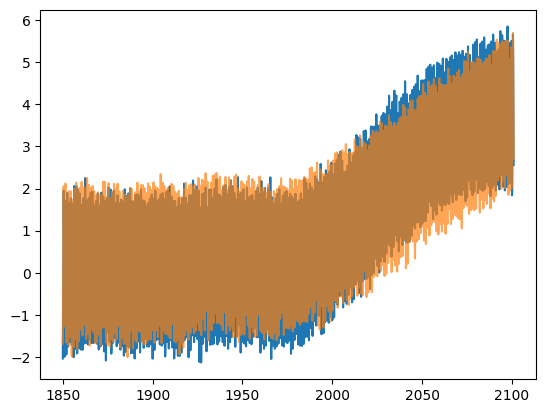

In [22]:
plt.plot(ssp245_data['month'].T.values/12+1850,fast_global_means[0][1200:], label='Fast method realization 1')
plt.plot(ssp245_data['month'].T.values/12+1850, original_global_mean.T.values, label='Original CESM2 SSP245', alpha=0.7)

In [ ]:
# Generate ensemble with climatology added efficiently!
n_members = 5

import time
start = time.time()

# Use monthly_prediction as the base - this is the METEOR pattern-scaled output
# The noise model will add stochastic variability ON TOP of this
ensemble_members = tas_noise_model.generate_realization(
    monthly_warming,
    n_realizations=n_members,
    noise_only=True,
    random_seed=99,
    add_base=monthly_prediction  # Correct! Pattern prediction with matching dimensions
)

elapsed = time.time() - start
print(f"✅ Generated {n_members} members in {elapsed:.2f}s ({elapsed/n_members:.2f}s per member)")



In [ ]:
# Test self-consistent multi-region generation
print("\n🔗 Testing SELF-CONSISTENT multi-region generation:")
print("="*70)

# Generate stochastic PCs once
start = time.time()
pcs = tas_noise_model.generate_stochastic_pcs(
    monthly_warming,
    n_realizations=50,
    random_seed=42
)
elapsed_pcs = time.time() - start

print(f"✅ Generated stochastic PCs: {pcs.shape}")
print(f"   Time: {elapsed_pcs:.2f}s")

# Use same PCs for multiple regions
start = time.time()
global_means_consistent = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='global',
    stochastic_pcs=pcs,
    noise_only=True,
    add_base=monthly_prediction_global_mean
)
elapsed_global = time.time() - start

# Compute NEU regional mean of monthly_prediction for add_base
monthly_prediction_neu_mean = calculate_regional_mean(monthly_prediction, 'NEU')

start = time.time()
neu_means_consistent = tas_noise_model.generate_regional_mean_realizations(
    monthly_warming,
    region='NEU',
    stochastic_pcs=pcs,
    noise_only=True,
    add_base=monthly_prediction_neu_mean
)
elapsed_neu = time.time() - start

print(f"\n✅ Generated consistent regional means:")
print(f"   Global: {len(global_means_consistent)} realizations in {elapsed_global:.2f}s")
print(f"   NEU:    {len(neu_means_consistent)} realizations in {elapsed_neu:.2f}s")
print(f"\n💡 These share the same stochastic variability!")
print(f"   Total time: {elapsed_pcs + elapsed_global + elapsed_neu:.2f}s for 100 time series")
print("="*70)

## 8. Calculate Global Means and Create Visualization

In [ ]:
# Calculate global means for ensemble members
print("📊 Calculating global means for ensemble members...")

ensemble_global_means = []
for i, member in enumerate(ensemble_members):
    global_mean = calculate_global_mean(member)
    ensemble_global_means.append(global_mean)
    


In [ ]:
# Create the comparison plot
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

# Create time axes
# Ensemble members are in monthly resolution starting from some base year
n_months_ensemble = len(ensemble_global_means[0])
start_year_ensemble = 1850  # Typical CMIP6 start
time_ensemble = start_year_ensemble + np.arange(n_months_ensemble) / 12

# Original data time axis (annual)

# Define colors
ensemble_color = '#4472C4'  # Blue
original_color = '#ED7D31'  # Orange/red

# Plot ensemble members
for i, member_mean in enumerate(ensemble_global_means):
    ax.plot(time_ensemble, member_mean.values, 
            color=ensemble_color, alpha=0.35, linewidth=1.5, 
            label='METEOR ensemble members' if i == 0 else '')
#ssp245_data['year'] = (ssp245_data['month'] / 12) + 1850
# Plot original CESM2 data
ax.plot(ssp245_data['month'].T.values/12+1850, original_global_mean.T.values, 
        color=original_color, linewidth=3, 
        label=f'Original {model_name} SSP245', 
        zorder=10, marker='o', markersize=3, markevery=5)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Global Mean Temperature (K)', fontsize=13, fontweight='bold')
ax.set_title(f'{model_name} SSP245: 10-Member METEOR Ensemble vs Original\nGlobal Mean Surface Air Temperature', 
             fontsize=14, fontweight='bold', pad=15)

ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=ensemble_color, alpha=0.35, edgecolor='black', 
          label=f'METEOR ensemble (n={n_members})'),
    plt.Line2D([0], [0], color=original_color, linewidth=3, marker='o', 
               markersize=5, label=f'Original {model_name}')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left', 
          framealpha=0.95, edgecolor='black')

# Set reasonable x-axis limits (focus on future period)
ax.set_xlim(2024, 2030)

plt.tight_layout()
plt.show()

print("✅ Visualization complete!")

In [ ]:
# Calculate regional means for NEU (Northern Europe)
print("📊 Calculating NEU regional means for ensemble members...")

region_code = "NEU"

# Calculate for ensemble members
ensemble_regional_means = []
for i, member in enumerate(ensemble_members):
    regional_mean = calculate_regional_mean(member, region_code)
    ensemble_regional_means.append(regional_mean)
    print(f"   Member {i+1}/{n_members} complete")

# Calculate for original data
original_regional_mean = calculate_regional_mean(ssp245_data, region_code)
print(f"✅ NEU regional means calculated")
print(f"   Region: {original_regional_mean.attrs['region_name']}")


In [ ]:
# Create the NEU regional comparison plot
fig, ax = plt.subplots(figsize=(14, 7), dpi=120)

# Create time axes (same as global mean plot)
n_months_ensemble = len(ensemble_regional_means[0])
start_year_ensemble = 1850
time_ensemble = start_year_ensemble + np.arange(n_months_ensemble) / 12

# Define colors
ensemble_color = '#4472C4'  # Blue
original_color = '#ED7D31'  # Orange/red

# Plot ensemble members
for i, member_mean in enumerate(ensemble_regional_means):
    ax.plot(time_ensemble, member_mean.values, 
            color=ensemble_color, alpha=0.35, linewidth=1.5, 
            label='METEOR ensemble members' if i == 0 else '')

# Plot original CESM2 data
ax.plot(ssp245_data['month'].values/12 + 1850, original_regional_mean.T.values, 
        color=original_color, linewidth=3, 
        label=f'Original {model_name} SSP245', 
        zorder=10, marker='o', markersize=3, markevery=5)

# Formatting
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Regional Mean Temperature (K)', fontsize=13, fontweight='bold')
ax.set_title(f'{model_name} SSP245: 10-Member METEOR Ensemble vs Original\n{original_regional_mean.attrs["region_name"]} ({region_code}) Surface Air Temperature', 
             fontsize=14, fontweight='bold', pad=15)

ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.8)
ax.set_axisbelow(True)

# Legend
legend_elements = [
    Patch(facecolor=ensemble_color, alpha=0.35, edgecolor='black', 
          label=f'METEOR ensemble (n={n_members})'),
    plt.Line2D([0], [0], color=original_color, linewidth=3, marker='o', 
               markersize=5, label=f'Original {model_name}')
]
ax.legend(handles=legend_elements, fontsize=11, loc='upper left', 
          framealpha=0.95, edgecolor='black')

# Set reasonable x-axis limits (focus on future period)
ax.set_xlim(2024, 2030)

plt.tight_layout()
plt.show()

print(f"✅ {region_code} regional visualization complete!")
